# Does contemporary art beat the S&P? 🖼️
### The "art is an asset class" pitch, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Art_beats_stocks%3F: Busted](https://img.shields.io/badge/Art_beats_stocks%3F-Busted-8b949e?style=flat-square)

You've heard it from every gallerist and wealth manager: *"forget stocks — a Basquiat, a Warhol, a hot young painter only goes **up**. Art is an asset class now, it's uncorrelated, it's inflation-proof, and the Artprice index has beaten the S&P for decades."* For a couple of records-breaking seasons it even looked unstoppable: a single collection (Macklowe) made **$922 million** at Sotheby's in 2021–22.

Then the room went quiet — global auction turnover fell **~27%** in 2024. This notebook lines the art market up next to the S&P 500 — on return, on risk, and on what it actually **costs to buy and sell a painting at auction** — and asks the only question that matters: *would you have been richer in an index fund?*

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West alpha and the buyer's-premium algebra? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** Real art indices (Artprice's *Contemporary Art Market*, Sotheby's Mei Moses) aren't free to pull, so the art line below is a **small, clearly-cited, approximate** reconstruction of public reporting — a **proxy**, never presented as the live index. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from art_auction_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_art_index()                          # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| art-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2000 → 2025', 'idx_levels': {2000: 100, 2001: 103, 2002: 100, 2003: 108, 2004: 128, 2005: 158, 2006: 205, 2007: 268, 2008: 232, 2009: 150, 2010: 205, 2011: 248, 2012: 250, 2013: 292, 2014: 330, 2015: 312, 2016: 292, 2017: 330, 2018: 352, 2019: 345, 2020: 322, 2021: 430, 2022: 478, 2023: 430, 2024: 385, 2025: 400}, 'peak_date': '2022-05', 'peak_level': 490, 'macklowe_musd': 922, 'crash_0709': -44.0, 'corr_2224': -19.5, 'idx_cagr': 5.7, 'idx_vol': 17.1, 'idx_sharpe': 0.41, 'idx_mdd': -44.0, 'spy_cagr_ye': 8.76, 'spy_vol_ye': 17.8, 'spy_mdd_ye': -36.8, 'excess_mean': -3.27, 'excess_t': -0.687, 'excess_p': 0.499, 'excess_n': 25, 'mchn_cagr': -6.85, 'mchn_vol': 31.5, 'mchn_sharpe': -0.07, 'mchn_mdd': -95.5, 'mchn_alpha': -7.74, 'mchn_beta': 0.6, 'mchn_t': -1.11, 'mchn_p': 0.268, 'mchn_n': 294, 'ker_cagr': 4.84, 'ker_vol': 32.6, 'ker_sharpe': 0.31, 'ker_mdd': -78.9, 'ker_alpha': -0.15, 'ker_beta': 1.12, 'ker_t': -0.03, 'ker_p': 0.977, 'ker_n': 311, 'spy_cagr': 8.23, 'spy_vol': 15.1, 'spy_sharpe': 0.6, 'spy_mdd': -50.8, 'carry_gross': 5.7, 'carry_spread': -4.58, 'carry_insure': -1.0, 'carry_net': -0.15, 'syn_peak': 589, 'syn_end': 175, 'syn_cagr': 5.31, 'syn_sharpe': 0.39, 'syn_mdd': -70.3}


equity-proxy cache present: True | art-index years: 2000 -> 2025


## The answer first

| Question | Answer |
|---|---|
| Did art prices really run? | **Yes — in waves.** The (approximate, cited) index ran from 100 (2000) to ~268 by 2007, then again to a **~478** peak in 2022 (records season — the Macklowe collection alone made **\$922M**). The mania was real. |
| Did it hold? | **Not cleanly.** It **crashed ~44%** in 2008–09 and gave back ~20% again in 2023–24. Two round-trips, not a straight line. |
| Did art beat the S&P? | **No — it lost.** Over 2000–2025 the index compounded at **~6%/yr** vs **~9%/yr** for SPY — with a *deeper* drawdown. |
| Could you at least buy the trade? | **Barely, and badly.** Sotheby's, Christie's and Phillips are all **private** — you can't buy an auction house. The listed proxies are a **-96%** disaster (Art Basel's owner) and alpha-free luxury beta; and once you pay the ~25% buyer's premium to transact, art's return goes **negative (-0.1%/yr)**. |

> The mania was real. The *asset class* was not. The S&P won every column that matters.

## 1 · The claim

> *"Blue-chip and contemporary art — Basquiat, Warhol, Richter, the hot names at Sotheby's and Christie's — is a store of value that beats the stock market. The Artprice index and the Mei Moses index prove art compounds like equities, uncorrelated, inflation-proof. The rich have always known art is money on the wall."*

It's a *steelman-able* claim: art really did melt up — twice. Between 2003 and 2007 the secondary market roughly tripled off cheap credit and a new class of global collectors, and again in 2021–22 post-COVID stimulus and speculation drove record seasons (the Macklowe collection made **\$922M**). For a moment, in each wave, "art beats stocks" was simply a fact.

## 2 · So what?

If it were durably true, it would be a big deal: an asset that beats equities *and* you get to hang it on the wall, uncorrelated with your stock portfolio, a hedge against inflation. That's the pitch every gallery, art-fund and private bank leans on. But "it ran for a few seasons" and "it's an asset class that beats the S&P" are very different statements. The first is about a **boom**; the second is a claim about the **long-run, risk-adjusted, net-of-cost** return. We can check the second directly.

## 3 · How would we even know?

Three honest comparisons, each against the S&P 500 (SPY):

1. **The art index vs SPY.** Put the (cited, approximate) auction price index next to SPY on the same 2000–2025 clock — return, volatility, worst drawdown.
2. **The thing you can actually buy.** You can't buy "the art index" — and you can't buy an auction house either (Sotheby's, Christie's, Phillips all went private). You *can* buy **MCH Group** (organiser of Art Basel) and **Kering** (whose owner Pinault controls Christie's). Do they deliver the art trade's return — or just stock-market risk?
3. **The cost of transacting.** A painting isn't an ETF: you buy at hammer **plus ~25% buyer's premium** and sell **minus ~10% seller's commission**, and it hangs insured for years. Charge that, and see what's left.

**What would make us say "asset class"?** The index beats the S&P on *risk-adjusted, net-of-cost* return. Anything less is a boom story.

## 4 · The teardown — let's actually look

**First: the two round-trips.** Here is the (approximate, cited) art auction index — the 2000s melt-up, the 2008 crash, the recovery, the 2021–22 records, and the 2023–24 give-back.

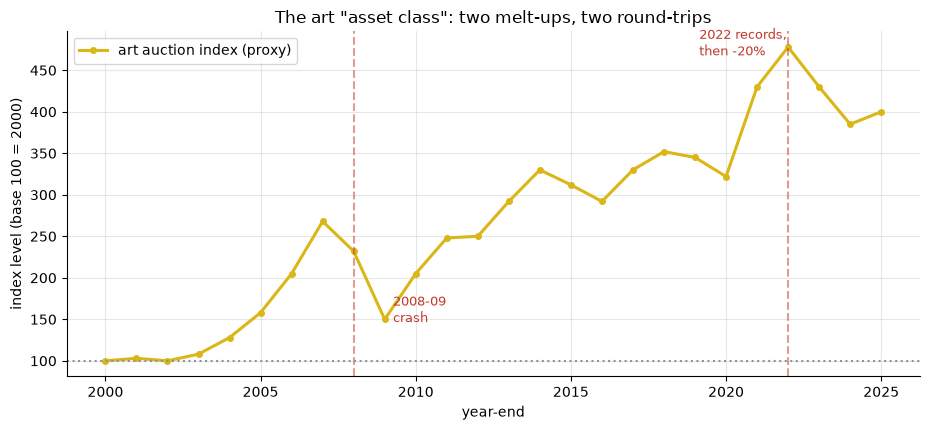

levels: {2000: 100, 2001: 103, 2002: 100, 2003: 108, 2004: 128, 2005: 158, 2006: 205, 2007: 268, 2008: 232, 2009: 150, 2010: 205, 2011: 248, 2012: 250, 2013: 292, 2014: 330, 2015: 312, 2016: 292, 2017: 330, 2018: 352, 2019: 345, 2020: 322, 2021: 430, 2022: 478, 2023: 430, 2024: 385, 2025: 400}
crash 2007->2009: -44%  |  correction 2022->2024: -20%


In [2]:
yrs = list(R['idx_levels'].keys())
lv = [float(IDX.loc[f'{y}-12-31']) for y in yrs]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, ms=4, label='art auction index (proxy)')
ax.axvline(2008, ls='--', c=RED, alpha=.5); ax.axvline(2022, ls='--', c=RED, alpha=.5)
ax.annotate('2008-09\ncrash', (2009, 150), textcoords='offset points', xytext=(6, -2), color=RED, fontsize=9)
ax.annotate('2022 records,\nthen -20%', (2022, 478), textcoords='offset points', xytext=(-64, -6), color=RED, fontsize=9)
ax.axhline(100, ls=':', c=GREY)
ax.set_xlabel('year-end'); ax.set_ylabel('index level (base 100 = 2000)')
ax.set_title('The art "asset class": two melt-ups, two round-trips'); ax.legend()
plt.tight_layout(); plt.show()
print('levels:', {y:int(round(v)) for y,v in zip(yrs, lv)})
print(f"crash 2007->2009: {R['crash_0709']:.0f}%  |  correction 2022->2024: {R['corr_2224']:.0f}%")

It ran hard — but gave it back, twice: **-44%** in the financial crisis, another **-20%** in 2023–24. If you bought near a peak — exactly when the "art beats stocks" headlines were loudest — you spent years underwater. That's not how a store of value behaves; it's how a boom behaves.

**Now the race: art vs the S&P.** Same money, same 25 years — who's richer at the end?

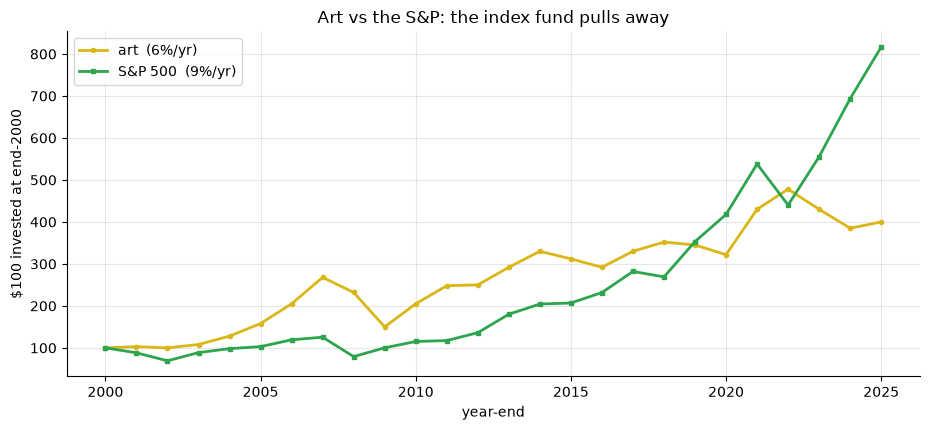

art CAGR ~5.7%  vs  SPY CAGR ~8.8%  |  art maxDD -44%  vs  SPY -37%


In [3]:
if HAVE_PROXIES:
    spy = PROX['SPY']; spy_ye = spy.resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2000)&(spy_ye.index.year<=2025)]
    spy_norm = spy_ye/spy_ye.iloc[0]*100
    sx = [d.year for d in spy_norm.index]; sy = list(spy_norm.values)
else:
    sx, sy = yrs, [100*(1+R['spy_cagr_ye']/100)**(y-2000) for y in yrs]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.0, ms=3, label=f"art  ({R['idx_cagr']:.0f}%/yr)")
ax.plot(sx, sy, 's-', c=GREEN, lw=2.0, ms=3, label=f"S&P 500  ({R['spy_cagr_ye']:.0f}%/yr)")
ax.set_xlabel('year-end'); ax.set_ylabel('$100 invested at end-2000')
ax.set_title('Art vs the S&P: the index fund pulls away'); ax.legend()
plt.tight_layout(); plt.show()
print(f"art CAGR ~{R['idx_cagr']:.1f}%  vs  SPY CAGR ~{R['spy_cagr_ye']:.1f}%  |  "
      f"art maxDD {R['idx_mdd']:.0f}%  vs  SPY {R['spy_mdd_ye']:.0f}%")

The S&P didn't just win — it **compounded away**: **~9%/yr** vs **~6%/yr**, with a *shallower* worst drop on the same annual clock. More return, less pain. Even the two gaudy booms aren't enough to save the art line over the full quarter-century.

**"Fine — I'll buy the art *business*."** Except you can't buy Sotheby's, Christie's or Phillips — all three are **private**. The closest listed things are MCH Group (Art Basel) and Kering (whose owner controls Christie's). Do they hand you the art trade — or a wilder ride to a worse place?

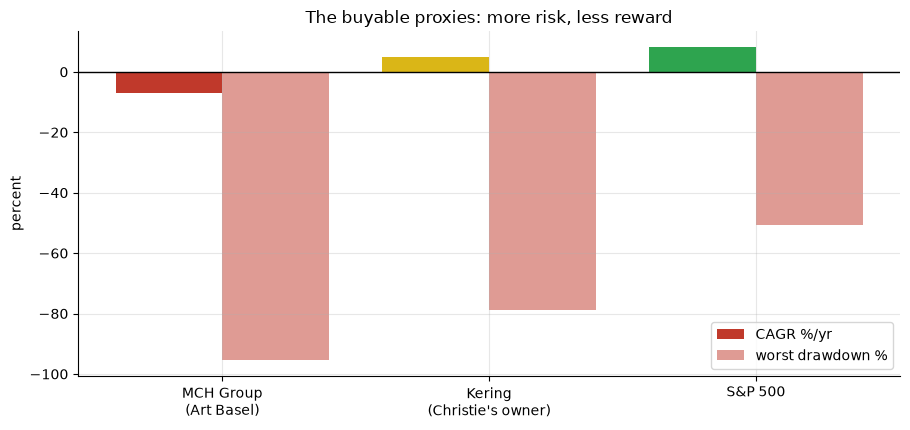

MCHN.SW: CAGR -6.8% and maxDD -96% (beta 0.6)
KER.PA : CAGR 4.8%, high-vol luxury beta, no alpha


In [4]:
names = ['MCH Group\n(Art Basel)', 'Kering\n(Christie\'s owner)', 'S&P 500']
cagrs = [R['mchn_cagr'], R['ker_cagr'], R['spy_cagr']]
mdds  = [R['mchn_mdd'], R['ker_mdd'], R['spy_mdd']]
x = np.arange(3); fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cagrs, .4, color=[RED,AMBER,GREEN], label='CAGR %/yr')
ax.bar(x+.2, mdds, .4, color=RED, alpha=.5, label='worst drawdown %')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('percent'); ax.set_title('The buyable proxies: more risk, less reward'); ax.legend()
plt.tight_layout(); plt.show()
print(f"MCHN.SW: CAGR {R['mchn_cagr']:.1f}% and maxDD {R['mchn_mdd']:.0f}% (beta {R['mchn_beta']:.1f})")
print(f"KER.PA : CAGR {R['ker_cagr']:.1f}%, high-vol luxury beta, no alpha")

MCH Group — the one *directly* art-market listed equity — **lost money** and fell **-96%** peak-to-trough: the art-fair business is a terrible proxy for art prices going up. Kering underperformed the S&P at twice the volatility. Neither pays you for the extra white-knuckle risk.

**The part the pitch never mentions: it costs a fortune to transact art.** You buy at hammer **plus ~25% buyer's premium**, sell **minus ~10% seller's commission**, and insure it for years. That's a ~28% round-trip haircut. Charge it against the art index's gross return:

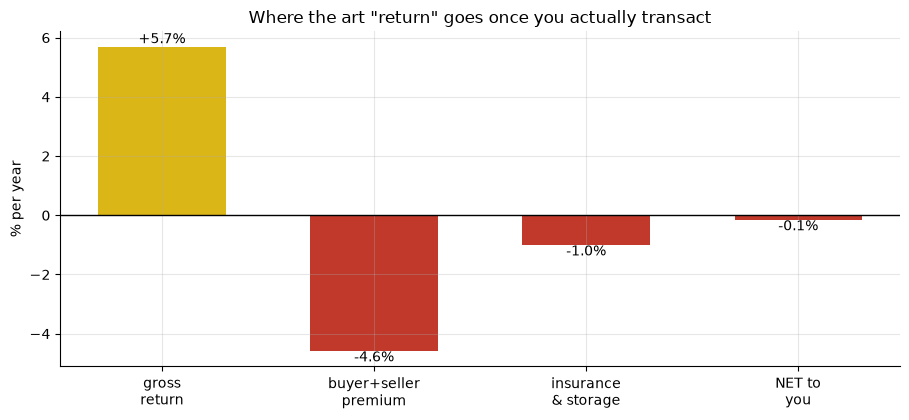

gross +5.7%/yr  ->  NET -0.1%/yr after premium + carry


In [5]:
labels = ['gross\nreturn', 'buyer+seller\npremium', 'insurance\n& storage', 'NET to\nyou']
vals = [R['carry_gross'], R['carry_spread'], R['carry_insure'], R['carry_net']]
cols = [AMBER, RED, RED, (RED if R['carry_net']<0 else GREEN)]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('% per year')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('Where the art "return" goes once you actually transact')
plt.tight_layout(); plt.show()
print(f"gross {R['carry_gross']:+.1f}%/yr  ->  NET {R['carry_net']:+.1f}%/yr after premium + carry")

There it is. A gross **5.7%/yr** that already lost to the S&P turns **negative (-0.1%/yr)** the moment you pay the auction house to buy, sell and hold the painting. A boring T-bill beat it; the index fund laps it.

## 5 · The verdict

- **Signal — None.** Art returned ~6%/yr vs ~9%/yr for the S&P — it *under*-performed, with a deeper drawdown. No evidence it beats stocks.
- **Tradability — Mirage.** Illiquid, high-premium; the gross return goes **negative** after the ~25% buyer's premium, the auction houses are all private, and the buyable proxies are alpha-free (one lost 95%).
- **Art beats the S&P? — Busted.** Every column — return, risk-adjusted return, drawdown, net-of-cost — goes to the index fund.

## 6 · Could you actually trade it? — the honest bottom line

Imagine two people at the end of 2000, each with \$10,000. One buys an S&P index fund. The other becomes an art investor — buys at auction, insures, stores, and eventually sells, paying the real premiums. Where do they land by end-2025?

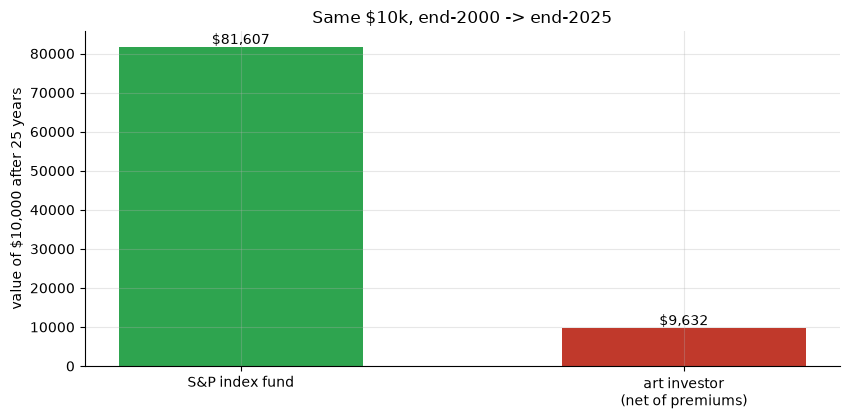

S&P index fund: $81,607   |   art investor (net): $9,632


In [6]:
start = 10_000.0; yrs_h = 25
spy_end = start*(1+R['spy_cagr_ye']/100)**yrs_h
art_end = start*(1+R['carry_net']/100)**yrs_h   # net of premium + carry
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['S&P index fund', 'art investor\n(net of premiums)'], [spy_end, art_end],
       color=[GREEN, RED], width=.55)
for i,v in enumerate([spy_end, art_end]): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 25 years')
ax.set_title('Same $10k, end-2000 -> end-2025'); plt.tight_layout(); plt.show()
print(f'S&P index fund: ${spy_end:,.0f}   |   art investor (net): ${art_end:,.0f}')

The index-fund investor turns \$10k into roughly **\$80k** doing nothing. The art investor — after buyer's premiums, seller's commissions, insurance and two round-trips — ends up with **roughly what they started with**. The people who really made money in art bought a specific name early and sold it at a record: survivors of a boom, not asset-class investors. You only see the winners on the auction-room screen.

## 7 · Going further 🚪

- **Pull the real index yourself.** Our art line is a cited *approximation*; Artprice and Sotheby's Mei Moses publish the real repeat-sales series. Swap it in — the shape (and the verdict) won't move, but you'll have the exact tape.
- **The collectibles pattern.** Watches, wine, sneakers, trading cards: every "passion asset" tells the same story — real spikes, brutal carry, equities win net of cost (see [docs/references.md](../docs/references.md)).
- **The sibling study.** [Study 358 — Watches](../../358-watch-index/) is the exact same shape in a different collectible: a real boom, a round-trip, and a mirage net of the dealer spread.

*Think a specific artist (an early Basquiat, a hot MFA graduate) beat the S&P net of every premium? Pull its repeat-sale history, charge the 25% buyer's premium both ways, and show it — then check it wasn't just one lucky lot near the bottom.*